# Testing BaselineGCN with refactored codebase

In [1]:
from torch.utils.data import random_split
import numpy as np
import importlib
import logging

# logging.basicConfig(
#     level=logging.INFO,
#     format='[%(asctime)s] %(levelname)s - %(message)s',
#     handlers=[
#         logging.FileHandler("dataset_loader.log"),
#         logging.StreamHandler()
#     ]
# )

In [2]:
from atoMLtype.datasets.GNNdataset import GNNdataset
from atoMLtype.models.ModelTrainer import GNNTrainer
from atoMLtype.analysis.metrics import plot_atom_distribution, plot_full_heatmap, \
    plot_category_heatmap, plot_detailed_cross_category_heatmap

from atoMLtype.models.ModelEncoder import ModelEncoder

gnn_dataset_encoder = ModelEncoder(collapse=True)

# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
gnn_test_dataset = GNNdataset(sdf_path, 
                              json_labels, 
                              directed_graph=False, 
                              labeled=True,
                              encoder=gnn_dataset_encoder)



[2025-04-16 15:33:33,755] INFO - atoMLtype.datasets.BaseDataset - Loaded atom type labels for 6410 molecules from ./data/antechamber/atomLabels_gaff2.json
[2025-04-16 15:33:33,787] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC03169274: 30 atoms in SDF, but 26 labels in JSON.
[2025-04-16 15:33:33,817] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC02569341: 19 atoms in SDF, but 34 labels in JSON.
[2025-04-16 15:33:33,908] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC10433799: 27 atoms in SDF, but 33 labels in JSON.
[2025-04-16 15:33:33,969] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC05731554: 25 atoms in SDF, but 26 labels in JSON.
[2025-04-16 15:33:34,029] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC55161679: 17 atoms in SDF, but 18 labels in JSON.
[2025-04-16 15:33:34,078] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC01581224: 18 

In [3]:
num_node_feat = gnn_test_dataset[0].x.shape[1]
# num_y_ATs = len(set(gnn_test_dataset.all_labels))

print(f"num_node_features = {num_node_feat}")
# print(f"num_y_ATs = {num_y_ATs}")

num_node_features = 154


FULL DATASET (raw):


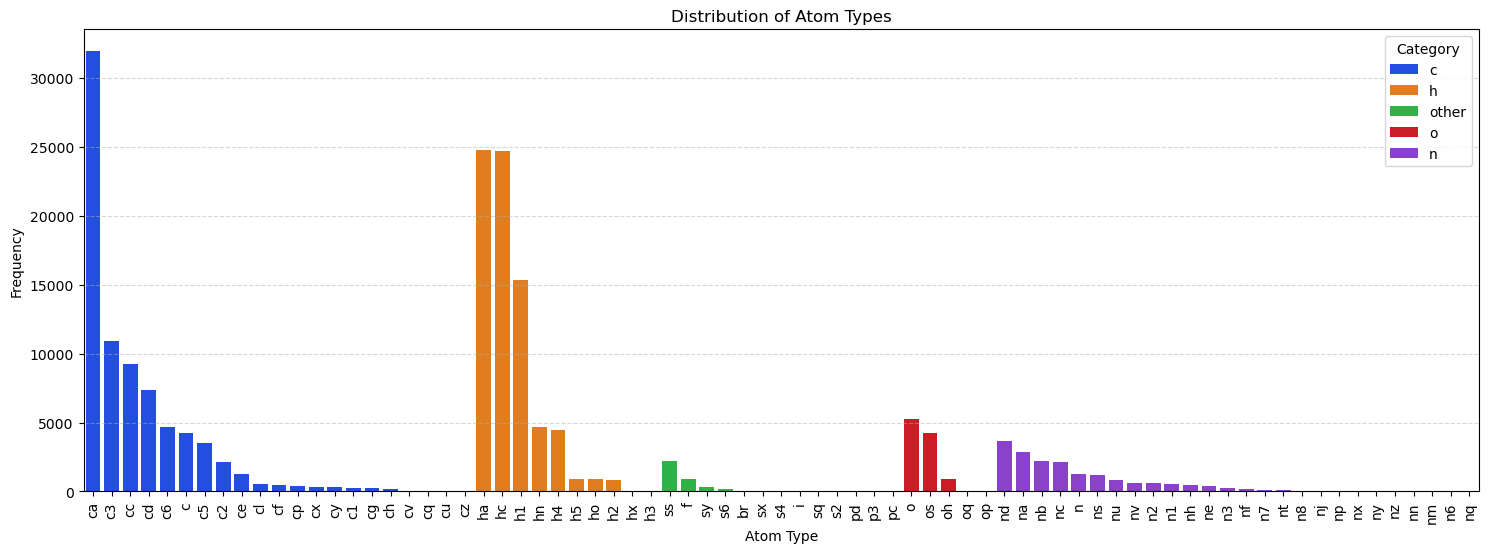

FULL DATASET (encoded):


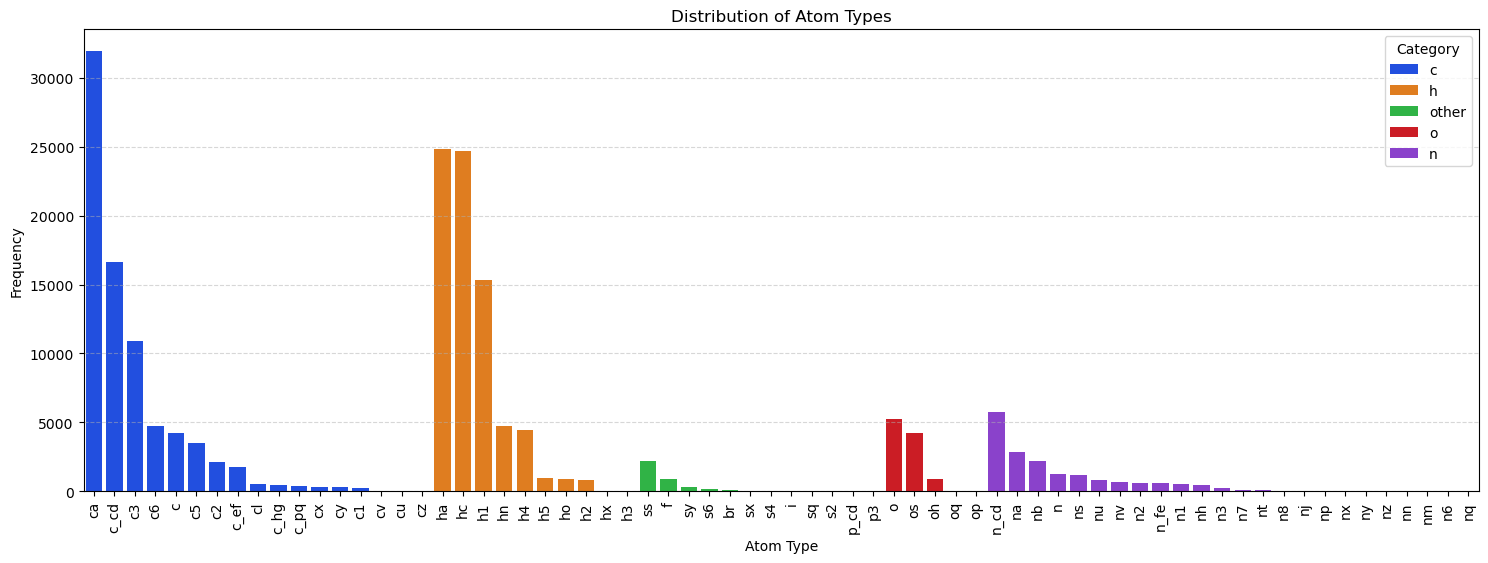

,Atom Type,Count,Category
0,ca,31919,c
1,c_cd,16619,c
2,c3,10891,c
3,c6,4710,c
4,c,4255,c
...,...,...,...
63,nz,4,n
64,nn,4,n
65,nm,3,n
66,n6,3,n


In [4]:
# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(gnn_test_dataset))
test_size = len(gnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(gnn_test_dataset, [train_size, test_size])

print("FULL DATASET (raw):")
plot_atom_distribution(np.array(gnn_test_dataset.raw_labels))

print("FULL DATASET (encoded):")
plot_atom_distribution(np.array(gnn_dataset_encoder.inverse_transform(gnn_test_dataset.encoded_labels)))



In [5]:
print(test_dataset[0].y)
print(train_dataset[0].y)

tensor([ 4,  7,  7,  7, 39, 37, 11, 40, 11, 40, 11, 40, 50,  4,  4, 25, 25, 25,
        24, 26, 26, 25, 25, 25, 25, 25, 25])
tensor([11, 11, 11, 11,  7,  7, 39, 67, 54, 54,  7,  7, 37,  7, 39,  7,  7, 65,
        12, 40, 11, 24, 24, 24, 22, 22, 22, 22])


BaselineGCN - Number of parameters: 376900
--- Fold 1/5 ---


Epoch 1: Train Loss = 1.6318, Val Loss = 0.9935
--- Fold 2/5 ---


Epoch 1: Train Loss = 0.6111, Val Loss = 0.6192
--- Fold 3/5 ---


Epoch 1: Train Loss = 0.5304, Val Loss = 0.5263
--- Fold 4/5 ---


Epoch 1: Train Loss = 0.4900, Val Loss = 0.4711
--- Fold 5/5 ---


Epoch 1: Train Loss = 0.4641, Val Loss = 0.4451


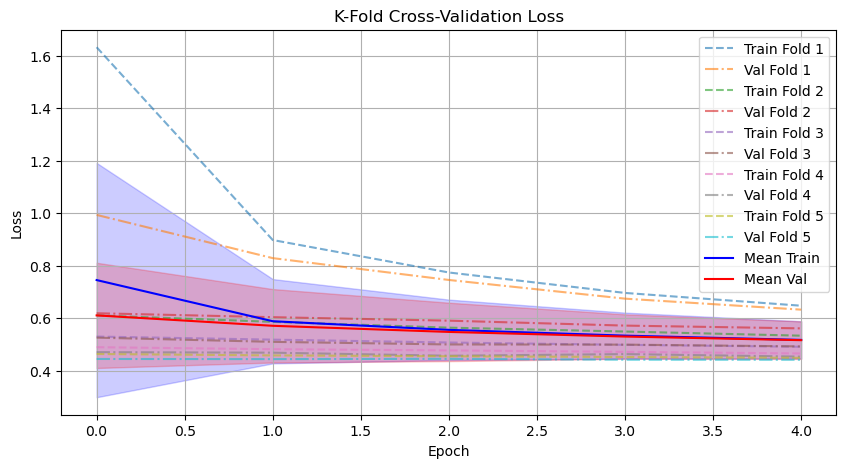

{'train_loss': [[1.6318471097687244,
   0.8978917931623073,
   0.7743203792698764,
   0.6965573216103581,
   0.6478809188594954],
  [0.6111492282531986,
   0.5864034398071412,
   0.5643562693412546,
   0.5495824235616082,
   0.533817099403134],
  [0.5304437818597902,
   0.5187173581613789,
   0.507841795413896,
   0.4989608393792733,
   0.4916308241949678],
  [0.49002197342430476,
   0.4823141357092771,
   0.4777777009238705,
   0.4722229718010196,
   0.46609128661967275],
  [0.464064085350156,
   0.458734359784414,
   0.455445770108319,
   0.45270541129770536,
   0.4492370558551109]],
 'val_loss': [[0.9935304202917566,
   0.829035298211839,
   0.7458785019098418,
   0.6747432885084994,
   0.6328915162648197],
  [0.6192160159017471,
   0.6042490304926367,
   0.5909503132545715,
   0.5721779039602806,
   0.5616069791557646],
  [0.5263415410923166,
   0.5102865865653438,
   0.5003717438711316,
   0.4997067337169796,
   0.4930131965721345],
  [0.4710537294435028,
   0.469115055418939,
   

In [6]:
from atoMLtype.models.GNN.BaselineGNNs import BaselineGCN



# Initialize BaselineGCN for classification
model = BaselineGCN(num_node_features=num_node_feat,
                    encoder=gnn_dataset_encoder, 
                    hidden_dim=512)
trainer = GNNTrainer(model,
                     dataset=train_dataset, 
                     batch_size=32, 
                     learning_rate=0.001,
                      epochs=5, 
                      k_folds=5, 
                      random_seed=21)
trainer.train(verbose=True)

In [7]:
print(test_dataset[0].y)
print(train_dataset[0].y)

tensor([ 4,  7,  7,  7, 39, 37, 11, 40, 11, 40, 11, 40, 50,  4,  4, 25, 25, 25,
        24, 26, 26, 25, 25, 25, 25, 25, 25])
tensor([11, 11, 11, 11,  7,  7, 39, 67, 54, 54,  7,  7, 37,  7, 39,  7,  7, 65,
        12, 40, 11, 24, 24, 24, 22, 22, 22, 22])


Prediction Summary: 15959/18785 correct (84.96% accuracy)
True label distribution: Counter({'ca': 3280, 'ha': 2537, 'hc': 2506, 'c_cd': 1668, 'h1': 1535, 'c3': 1089, 'n_cd': 566, 'o': 511, 'c6': 481, 'hn': 462, 'h4': 434, 'os': 425, 'c': 423, 'c5': 352, 'na': 273, 'ss': 245, 'nb': 239, 'c2': 204, 'c_ef': 188, 'n': 132, 'ns': 118, 'oh': 103, 'ho': 103, 'nu': 91, 'f': 79, 'h2': 75, 'h5': 73, 'nv': 68, 'n2': 67, 'cl': 57, 'n1': 48, 'n_fe': 47, 'c_hg': 45, 'c_pq': 32, 'nh': 31, 'cx': 29, 'c1': 29, 'sy': 26, 'cy': 26, 'n3': 25, 'n7': 12, 's6': 11, 'br': 9, 'nt': 8, 'hx': 7, 'sx': 4, 's4': 3, 'cu': 2, 'oq': 2, 'nx': 1, 'cv': 1, 'i': 1, 'n8': 1, 'h3': 1})
Pred label distribution: Counter({'ca': 3661, 'ha': 2539, 'hc': 2504, 'h1': 1538, 'c_cd': 1389, 'c3': 1238, 'c6': 576, 'n_cd': 558, 'o': 514, 'os': 487, 'hn': 462, 'h4': 433, 'c5': 408, 'na': 303, 'c': 299, 'nb': 271, 'ss': 249, 'nv': 189, 'ns': 120, 'ho': 102, 'oh': 99, 'f': 79, 'h2': 76, 'h5': 73, 'n': 67, 'c_hg': 60, 'cl': 57, 'n1': 48, '

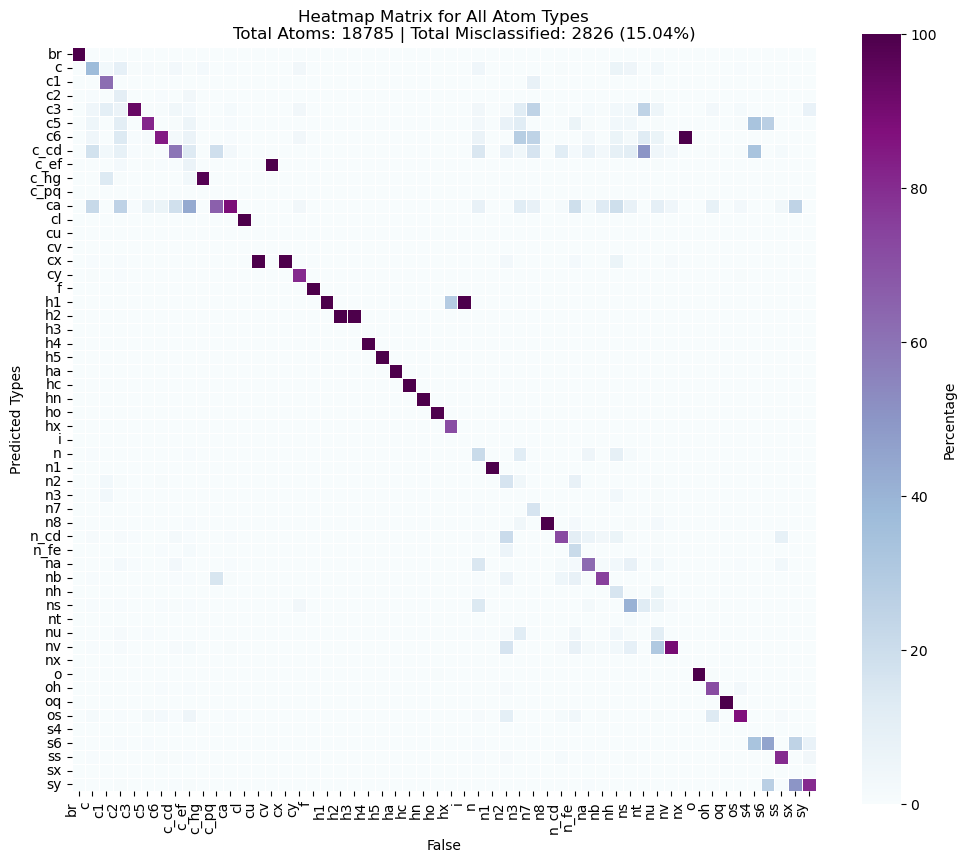

In [8]:
from atoMLtype.models.ModelEngine import ModelEngine


modelEngine = ModelEngine(model=model, 
                          dataset=test_dataset, 
                          device="cpu", 
                          batch_size=32)

predictionRecord = modelEngine.predict(analysis=False)

predictionRecord.summary()

plot_full_heatmap(y_true=predictionRecord.true_labels, y_pred=predictionRecord.pred_labels)

# Test DMPNN with refactored Codebase

In [9]:
mpnn_dataset_encoder = ModelEncoder(collapse=True)

# Initialize dataset
dataset_directed_labelled_collapsed = GNNdataset(sdf_path, 
                              json_labels, 
                              directed_graph=True, 
                              labeled=True,
                              encoder=mpnn_dataset_encoder)
num_node_feat = dataset_directed_labelled_collapsed[0].x.shape[1]
# num_y_ATs = len(set(dataset_directed_labelled_collapsed.all_labels))

print(f"num_node_features = {num_node_feat}")
# print(f"num_y_ATs = {num_y_ATs}")

[2025-04-16 15:37:13,037] INFO - atoMLtype.datasets.BaseDataset - Loaded atom type labels for 6410 molecules from ./data/antechamber/atomLabels_gaff2.json
[2025-04-16 15:37:13,104] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC03169274: 30 atoms in SDF, but 26 labels in JSON.
[2025-04-16 15:37:13,139] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC02569341: 19 atoms in SDF, but 34 labels in JSON.
[2025-04-16 15:37:13,225] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC10433799: 27 atoms in SDF, but 33 labels in JSON.
[2025-04-16 15:37:13,281] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC05731554: 25 atoms in SDF, but 26 labels in JSON.
[2025-04-16 15:37:13,350] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC55161679: 17 atoms in SDF, but 18 labels in JSON.
[2025-04-16 15:37:13,404] WARNING - atoMLtype.datasets.BaseDataset - Atom count mismatch for ZINC01581224: 18 

num_node_features = 154


FULL DATASET (raw):


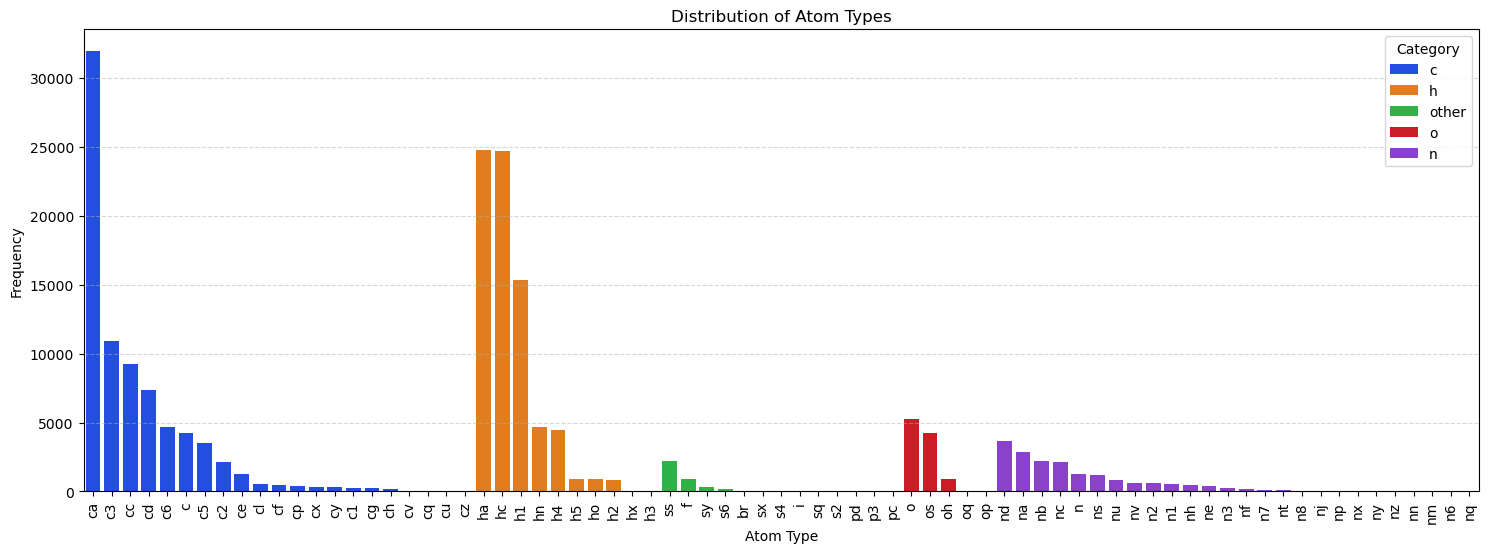

FULL DATASET (encoded):


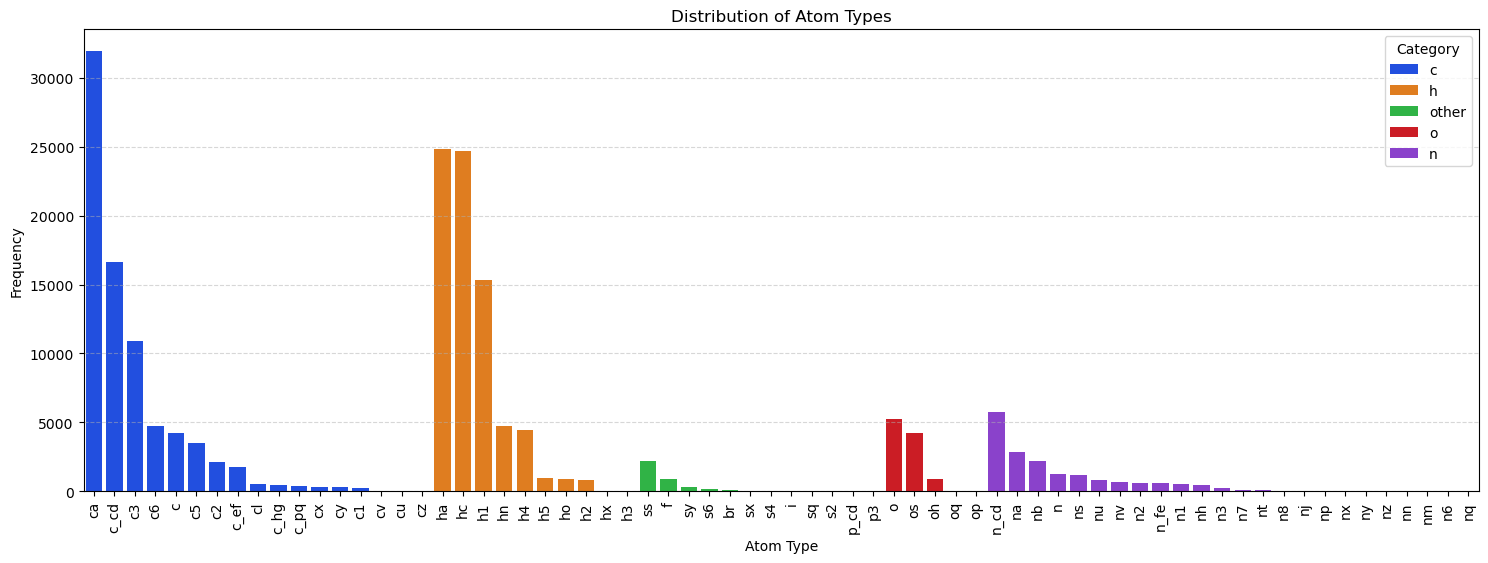

,Atom Type,Count,Category
0,ca,31919,c
1,c_cd,16619,c
2,c3,10891,c
3,c6,4710,c
4,c,4255,c
...,...,...,...
63,nz,4,n
64,nn,4,n
65,nm,3,n
66,n6,3,n


In [10]:
# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(dataset_directed_labelled_collapsed))
test_size = len(dataset_directed_labelled_collapsed) - train_size
train_dataset, test_dataset = random_split(dataset_directed_labelled_collapsed, [train_size, test_size])

print("FULL DATASET (raw):")
plot_atom_distribution(np.array(dataset_directed_labelled_collapsed.raw_labels))

print("FULL DATASET (encoded):")
plot_atom_distribution(np.array(gnn_dataset_encoder.inverse_transform(dataset_directed_labelled_collapsed.encoded_labels)))

AtomBondMPNN - Number of parameters: 10985550
--- Fold 1/5 ---


Epoch 1: Train Loss = 0.7119, Val Loss = 0.1966
Epoch 6: Train Loss = 0.0395, Val Loss = 0.0269
--- Fold 2/5 ---


Epoch 1: Train Loss = 0.0237, Val Loss = 0.0245
Epoch 6: Train Loss = 0.0165, Val Loss = 0.0185
--- Fold 3/5 ---


Epoch 1: Train Loss = 0.0176, Val Loss = 0.0162
Epoch 6: Train Loss = 0.0137, Val Loss = 0.0209
--- Fold 4/5 ---


Epoch 1: Train Loss = 0.0214, Val Loss = 0.0273
Epoch 6: Train Loss = 0.0095, Val Loss = 0.0147
--- Fold 5/5 ---


Epoch 1: Train Loss = 0.0100, Val Loss = 0.0146
Epoch 6: Train Loss = 0.0098, Val Loss = 0.0144


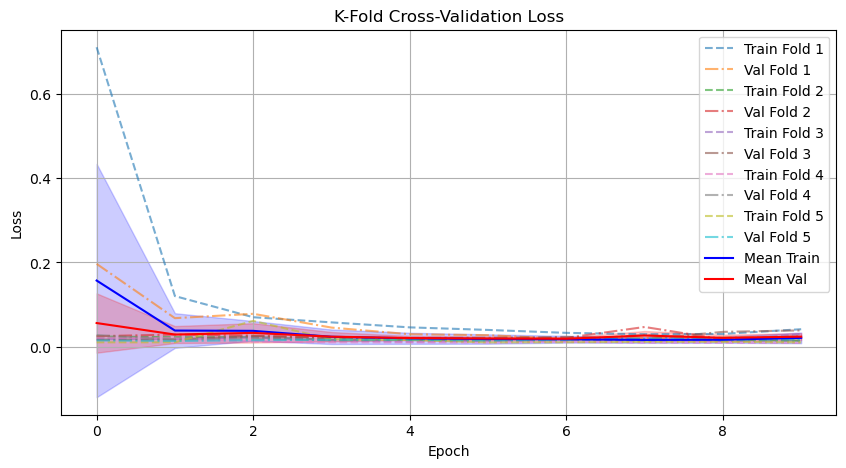

AtomBondMPNN - Number of parameters: 8323140
--- Fold 1/5 ---


Epoch 1: Train Loss = 0.8355, Val Loss = 0.1291
Epoch 6: Train Loss = 0.0635, Val Loss = 0.0320
--- Fold 2/5 ---


Epoch 1: Train Loss = 0.0295, Val Loss = 0.0274
Epoch 6: Train Loss = 0.0160, Val Loss = 0.0349
--- Fold 3/5 ---


Epoch 1: Train Loss = 0.0206, Val Loss = 0.0190
Epoch 6: Train Loss = 0.0341, Val Loss = 0.0499
--- Fold 4/5 ---


Epoch 1: Train Loss = 0.0166, Val Loss = 0.0195
Epoch 6: Train Loss = 0.0248, Val Loss = 0.0202
--- Fold 5/5 ---


Epoch 1: Train Loss = 0.0135, Val Loss = 0.0126
Epoch 6: Train Loss = 0.0127, Val Loss = 0.0200


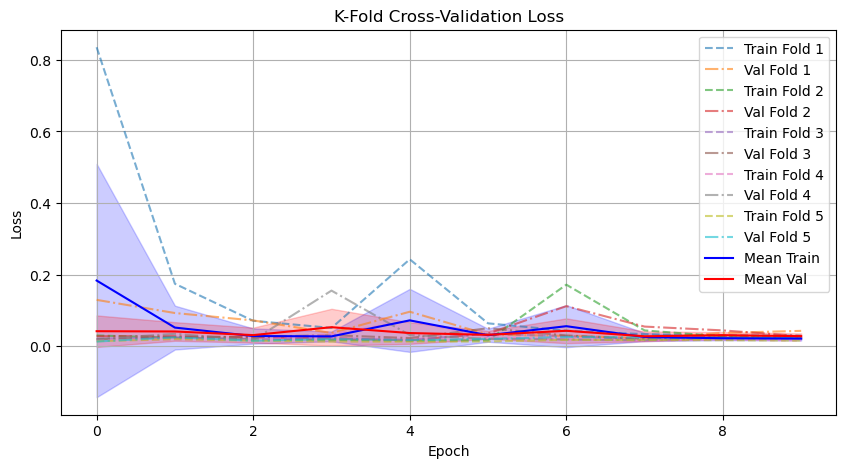

{'train_loss': [[0.8354930388223971,
   0.1741053542190521,
   0.07057613857369092,
   0.05057277180770283,
   0.24254015992588174,
   0.06350087739997012,
   0.04271996706054189,
   0.03309258621223324,
   0.02996187345573979,
   0.028930119270118997],
  [0.029545514460919773,
   0.02337616374460439,
   0.018807343270258226,
   0.017309949534962274,
   0.01525399113496627,
   0.01599237315186792,
   0.1715682316884269,
   0.04372417017556035,
   0.026826899072855587,
   0.023766460335226378],
  [0.020615991379711943,
   0.023569519456455183,
   0.018569201844271455,
   0.02159482330064908,
   0.017454920681320044,
   0.0340505380680681,
   0.027721130590092805,
   0.01789814486211401,
   0.017847543021942677,
   0.021352355694256836],
  [0.01659216274992696,
   0.017684074875441477,
   0.01697230666083345,
   0.03316104890582998,
   0.07117797378828973,
   0.02476338460252084,
   0.0183540602952801,
   0.014483599283642578,
   0.018127470044746224,
   0.015262953009376776],
  [0.01347

In [11]:
from atoMLtype.models.GNN.DMPNNmodel import AtomBondMPNN

# With Attention
model_AtomMPNN_att = AtomBondMPNN(atom_input_dim=dataset_directed_labelled_collapsed[0].x.shape[1], 
                                      bond_input_dim=dataset_directed_labelled_collapsed[0].edge_attr.shape[1], 
                                      hidden_dim=512,
                                      encoder=mpnn_dataset_encoder, 
                                      num_layers=10,
                                      use_attention=True)
trainer_AtomMPNN_att  = GNNTrainer(model_AtomMPNN_att, 
                                   dataset=train_dataset, 
                                   batch_size=32, learning_rate=0.001,
                                   epochs=10, 
                                   k_folds=5, 
                                   random_seed=21)
trainer_AtomMPNN_att.train(verbose=True)

# Without
model_AtomMPNN = AtomBondMPNN(atom_input_dim=dataset_directed_labelled_collapsed[0].x.shape[1], 
                                      bond_input_dim=dataset_directed_labelled_collapsed[0].edge_attr.shape[1], 
                                      hidden_dim=512,
                                      encoder=mpnn_dataset_encoder, 
                                      num_layers=10,
                                      use_attention=False)
trainer_AtomMPNN  = GNNTrainer(model_AtomMPNN,
                               dataset=train_dataset, 
                                batch_size=32, learning_rate=0.001,
                                epochs=10, 
                                k_folds=5, 
                                random_seed=21)
trainer_AtomMPNN.train(verbose=True)

In [12]:
modelEngine_att = ModelEngine(model=model_AtomMPNN_att, 
                          dataset=test_dataset, 
                          device="cpu",
                          batch_size=32)

MPNN_att_record = modelEngine_att.predict(analysis=False)


modelEngine = ModelEngine(model=model_AtomMPNN, 
                          dataset=test_dataset, 
                          device="cpu",
                          batch_size=32)

MPNN_record = modelEngine.predict(analysis=False)


In [13]:
MPNN_att_record.summary()

Prediction Summary: 18615/18695 correct (99.57% accuracy)
True label distribution: Counter({'ca': 3157, 'ha': 2548, 'hc': 2332, 'c_cd': 1701, 'h1': 1688, 'c3': 1099, 'n_cd': 583, 'o': 550, 'hn': 464, 'h4': 448, 'os': 439, 'c6': 429, 'c': 421, 'c5': 380, 'na': 293, 'ss': 236, 'c2': 227, 'nb': 197, 'c_ef': 166, 'n': 139, 'ns': 113, 'h5': 86, 'nu': 81, 'f': 77, 'h2': 72, 'oh': 67, 'ho': 67, 'n2': 61, 'nv': 58, 'n1': 56, 'c_pq': 48, 'cl': 47, 'n_fe': 46, 'c_hg': 41, 'nh': 37, 'sy': 34, 'c1': 31, 'n3': 29, 'cy': 29, 'cx': 25, 's6': 24, 'n7': 19, 'nt': 14, 'br': 12, 'cv': 6, 'n8': 4, 'h3': 3, 'nj': 2, 'sq': 2, 'np': 2, 's4': 1, 'nz': 1, 'i': 1, 'cu': 1, 'op': 1})
Pred label distribution: Counter({'ca': 3161, 'ha': 2548, 'hc': 2336, 'c_cd': 1705, 'h1': 1687, 'c3': 1098, 'n_cd': 586, 'o': 552, 'hn': 464, 'h4': 447, 'os': 442, 'c6': 430, 'c': 426, 'c5': 384, 'na': 295, 'ss': 236, 'c2': 217, 'nb': 191, 'c_ef': 161, 'n': 139, 'ns': 113, 'h5': 86, 'nu': 80, 'f': 77, 'h2': 72, 'oh': 67, 'ho': 67, '

In [14]:
MPNN_record.summary()

Prediction Summary: 18600/18695 correct (99.49% accuracy)
True label distribution: Counter({'ca': 3157, 'ha': 2548, 'hc': 2332, 'c_cd': 1701, 'h1': 1688, 'c3': 1099, 'n_cd': 583, 'o': 550, 'hn': 464, 'h4': 448, 'os': 439, 'c6': 429, 'c': 421, 'c5': 380, 'na': 293, 'ss': 236, 'c2': 227, 'nb': 197, 'c_ef': 166, 'n': 139, 'ns': 113, 'h5': 86, 'nu': 81, 'f': 77, 'h2': 72, 'oh': 67, 'ho': 67, 'n2': 61, 'nv': 58, 'n1': 56, 'c_pq': 48, 'cl': 47, 'n_fe': 46, 'c_hg': 41, 'nh': 37, 'sy': 34, 'c1': 31, 'n3': 29, 'cy': 29, 'cx': 25, 's6': 24, 'n7': 19, 'nt': 14, 'br': 12, 'cv': 6, 'n8': 4, 'h3': 3, 'nj': 2, 'sq': 2, 'np': 2, 's4': 1, 'nz': 1, 'i': 1, 'cu': 1, 'op': 1})
Pred label distribution: Counter({'ca': 3158, 'ha': 2546, 'hc': 2338, 'c_cd': 1706, 'h1': 1687, 'c3': 1098, 'n_cd': 579, 'o': 552, 'hn': 464, 'h4': 447, 'os': 442, 'c6': 434, 'c': 429, 'c5': 380, 'na': 288, 'ss': 236, 'c2': 225, 'nb': 193, 'c_ef': 163, 'n': 139, 'ns': 113, 'h5': 86, 'nu': 86, 'f': 77, 'h2': 72, 'oh': 67, 'ho': 67, '

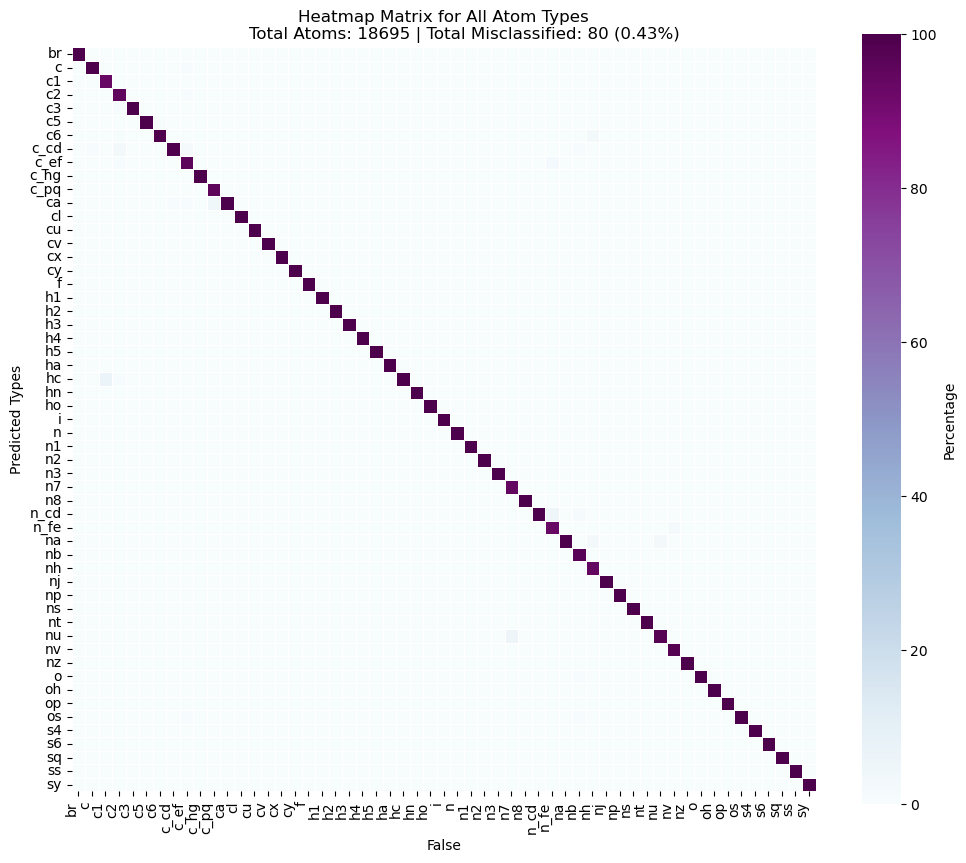

In [15]:
plot_full_heatmap(y_true=MPNN_att_record.true_labels, y_pred=MPNN_att_record.pred_labels )


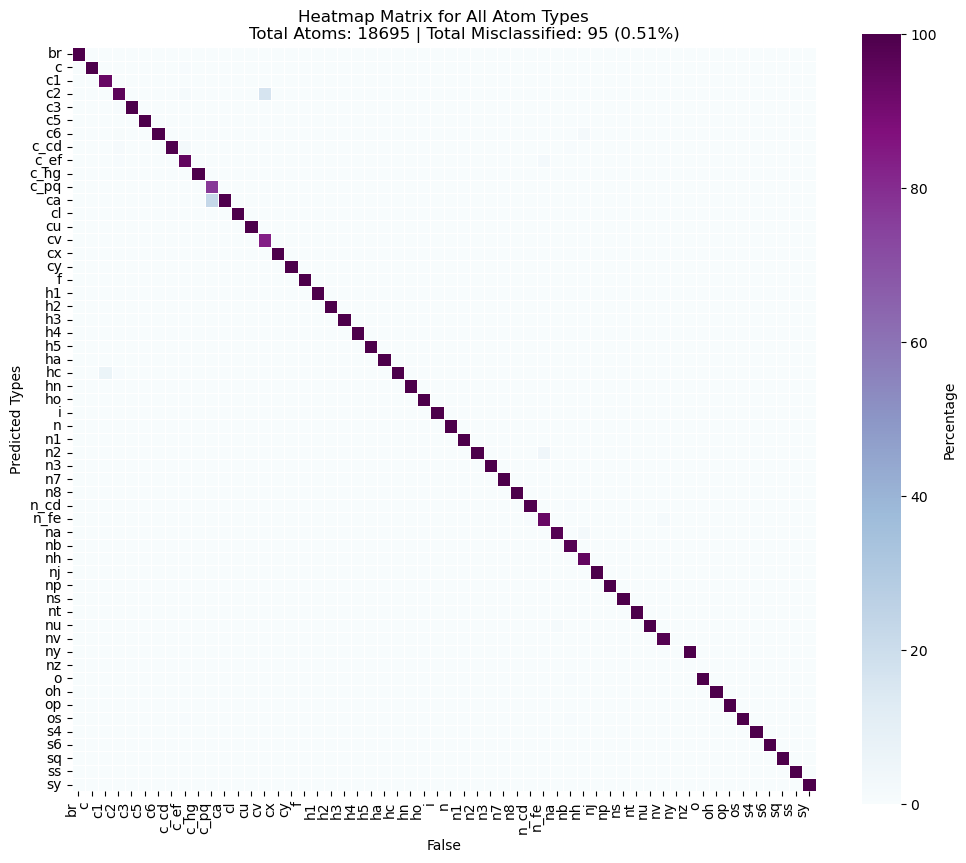

In [16]:

plot_full_heatmap(y_true=MPNN_record.true_labels, y_pred=MPNN_record.pred_labels )


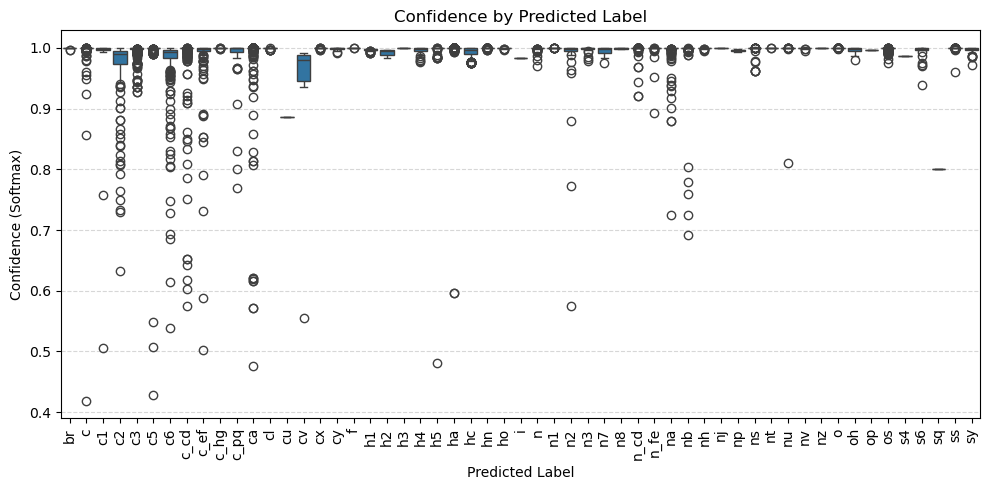

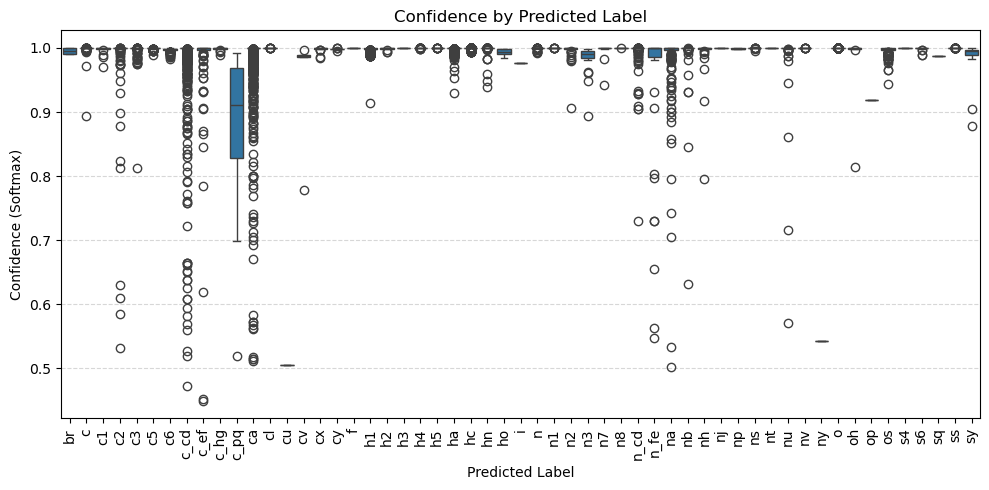

In [17]:
import atoMLtype.analysis.visualizations
importlib.reload(atoMLtype.analysis.visualizations)
from atoMLtype.analysis.visualizations import plot_confidence_by_pred_label

plot_confidence_by_pred_label(MPNN_att_record, 
                              sort_by='alphabetical', 
                              showfliers=True, 
                              figsize=(10, 5))

plot_confidence_by_pred_label(MPNN_record, 
                              sort_by='alphabetical', 
                              showfliers=True, 
                              figsize=(10, 5))

